In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('base_final_narino_cundinamarca.csv')
data.head(5)

,Departamento,Municipio,Año,Área Cosechada,Área Sembrada,Producción,Rendimiento,Precipitación acumulada anual (mm/año),Temperatura media anual (°C),Máximo de la temperatura media mensual (°C),...,SPI1_floracion,SPI3_floracion,SPI1_llenado,SPI3_llenado,altitud_media_m,Rendimiento_lag1,Rendimiento_lag2,Rendimiento_lag3,Rendimiento_rolling3,Rendimiento_vs_media_mun
0,CUNDINAMARCA,ANAPOIMA,2008,234.66,244.87,104.030,0.443322,9397.211458,21.052603,21.534576,...,0.034885,0.288161,-0.041813,0.090587,753.137185,0.410887,NaN,NaN,0.410887,0.000000
1,CUNDINAMARCA,ANAPOIMA,2009,238.67,244.42,109.322,0.458047,7596.002594,21.659576,22.564850,...,-0.147636,-0.076189,-0.367224,-0.240564,753.137185,0.443322,0.410887,NaN,0.427104,0.016218
2,CUNDINAMARCA,ANAPOIMA,2010,244.25,251.16,114.100,0.467144,10091.935886,21.505259,23.381012,...,0.060390,0.094568,0.601869,0.299247,753.137185,0.458047,0.443322,0.410887,0.437418,0.020628
3,CUNDINAMARCA,ANAPOIMA,2011,245.00,247.00,116.000,0.473469,8696.465524,21.023651,21.647125,...,0.015540,0.021867,0.398428,0.166396,753.137185,0.467144,0.458047,0.443322,0.456171,0.022294
4,CUNDINAMARCA,ANAPOIMA,2012,107.00,107.00,53.500,0.500000,7848.365871,21.446869,21.943756,...,-0.069946,-0.136889,-0.022393,0.012682,753.137185,0.473469,0.467144,0.458047,0.466220,0.022896


# Selección de Variables

## Variables a eliminar

In [3]:
# Variables que se eliminan porque la variable y (Rendimiento) se calcula a partir de ellas:
var_calc_rdto = ['Área Cosechada', 'Área Sembrada', 'Producción']

# Variables que se eliminan porque son calculadas a partir de la variable y (Rendimiento):
var_rdtos = ['Rendimiento_rolling3','Rendimiento_vs_media_mun']

# Variables a eliminar porque generan colinealidad ya que vienen de la misma fuente:
var_spi = ['SPI3_mean_anual', 'SPI3_min_anual', 'SPI3_meses_bajo_m1', 'SPI6_mean_anual',
           'SPI6_min_anual', 'SPI6_meses_bajo_m1', 'SPI12_mean_anual', 'SPI12_min_anual',
           'SPI12_meses_bajo_m1', 'SPI3_dic', 'SPI6_dic', 'SPI1_floracion','SPI1_llenado']

## Variables a dejar

- **Identificadores y Controles:** `Departamento`, `Municipio`, `Año`, `altitud_media_m.`

- **Variables de Inercia:** `Rendimiento_lag1` (captura la salud previa del cultivo).

- **Bloque Hídrico (Críticas):** `SPI3_floracion`, `SPI3_llenado`, `SPI12_dic` (sequía acumulada).

- **Bloque Térmico:** `Máximo de la temperatura media mensual (°C)`, `Mínimo de la temperatura media mensual (°C).`

- **Suelo y Evaporación:** `Humedad volumétrica media anual del suelo capa 2`, `Evaporación potencial acumulada anual.`

In [4]:
vars_model = ['Departamento', 'Municipio', 'Año', 'altitud_media_m', 'Rendimiento_lag1', 'SPI3_floracion',
               'SPI3_llenado', 'SPI12_dic', 'Máximo de la temperatura media mensual (°C)',
               'Mínimo de la temperatura media mensual (°C)', 'Humedad volumétrica media anual del suelo capa 2 (m³/m³)', 
               'Evaporación potencial acumulada anual (mm/año)']

X = data[vars_model]
X.head(5)

,Departamento,Municipio,Año,altitud_media_m,Rendimiento_lag1,SPI3_floracion,SPI3_llenado,SPI12_dic,Máximo de la temperatura media mensual (°C),Mínimo de la temperatura media mensual (°C),Humedad volumétrica media anual del suelo capa 2 (m³/m³),Evaporación potencial acumulada anual (mm/año)
0,CUNDINAMARCA,ANAPOIMA,2008,753.137185,0.410887,0.288161,0.090587,0.990945,21.534576,20.717682,0.413769,1299.164296
1,CUNDINAMARCA,ANAPOIMA,2009,753.137185,0.443322,-0.076189,-0.240564,-0.561965,22.564850,21.122711,0.413046,1404.643724
2,CUNDINAMARCA,ANAPOIMA,2010,753.137185,0.458047,0.094568,0.299247,1.536935,23.381012,19.950592,0.412928,1287.480217
3,CUNDINAMARCA,ANAPOIMA,2011,753.137185,0.467144,0.021867,0.166396,0.412532,21.647125,20.361969,0.416187,1266.982543
4,CUNDINAMARCA,ANAPOIMA,2012,753.137185,0.473469,-0.136889,0.012682,-0.330545,21.943756,20.838287,0.412506,1385.323385


## Valdación de Colinealidad

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = X[X.columns[3:]]

# Calculo del  VIF para cada variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                                             feature         VIF
6        Mínimo de la temperatura media mensual (°C)  802.414408
5        Máximo de la temperatura media mensual (°C)  800.258212
7  Humedad volumétrica media anual del suelo capa...  127.018831
0                                    altitud_media_m   27.469059
1                                   Rendimiento_lag1   10.992053
8     Evaporación potencial acumulada anual (mm/año)    6.592500
2                                     SPI3_floracion    4.375651
3                                       SPI3_llenado    3.220041
4                                          SPI12_dic    2.971144


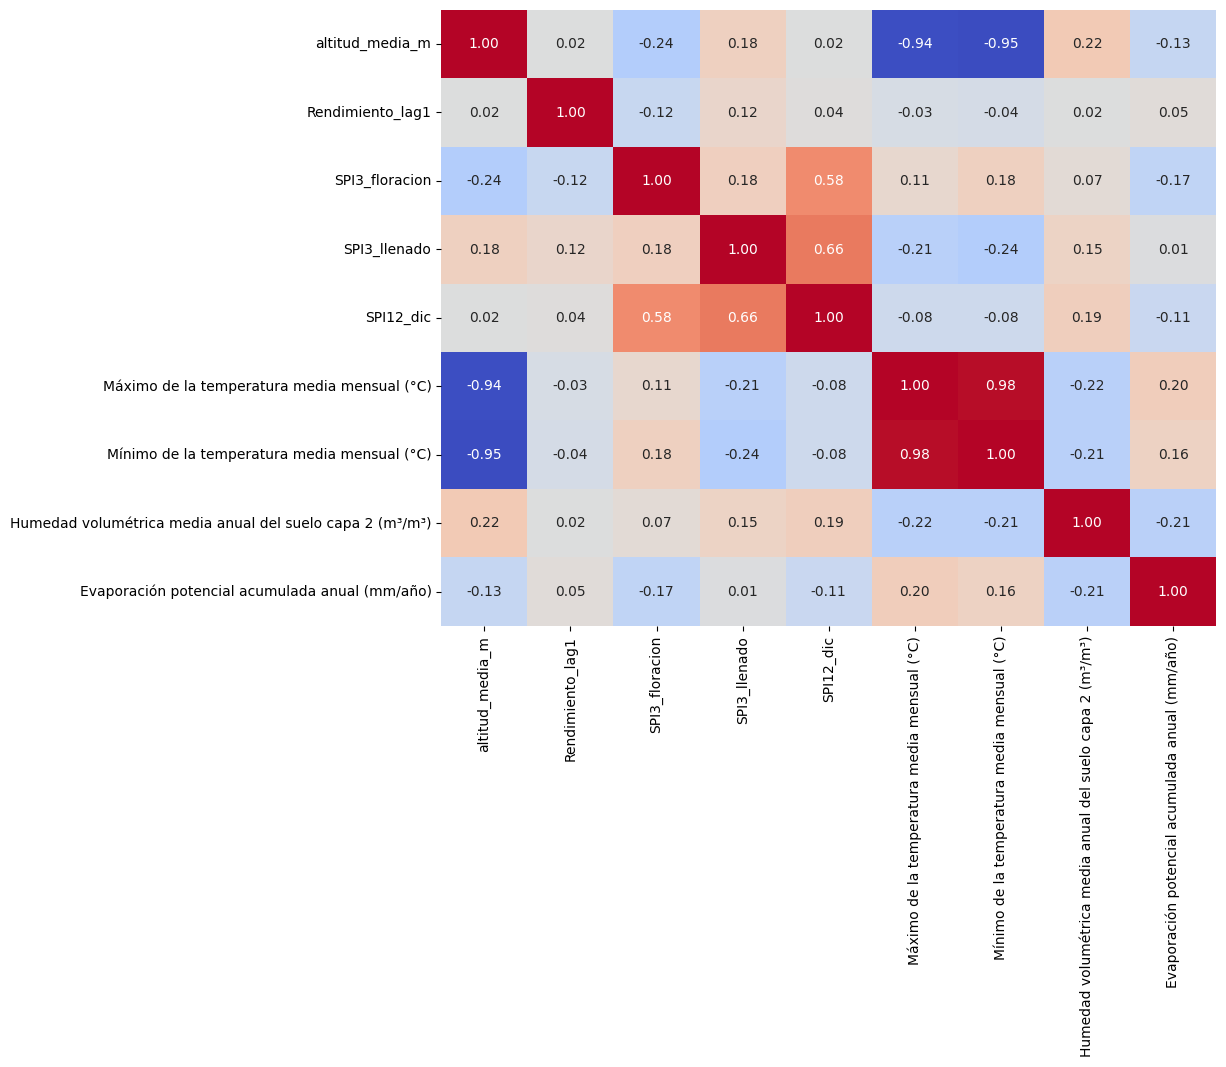

In [6]:
corr = X_num.corr()
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr, cbar=False, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [7]:
# Se elimina la temperatura mínima esta correlacionada con la temperatura minima
# Se elimina la altitud porque también esta correlacionada con la temperatura (pisos termicos)

x_2 = X_num.drop(['Mínimo de la temperatura media mensual (°C)','altitud_media_m'], axis = 1)

vif_data = pd.DataFrame()
vif_data["feature"] = x_2.columns
vif_data["VIF"] = [variance_inflation_factor(x_2.values, i) for i in range(len(x_2.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                                             feature        VIF
5  Humedad volumétrica media anual del suelo capa...  25.154664
4        Máximo de la temperatura media mensual (°C)  18.748242
0                                   Rendimiento_lag1  10.889534
6     Evaporación potencial acumulada anual (mm/año)   6.241864
1                                     SPI3_floracion   3.398609
2                                       SPI3_llenado   3.186880
3                                          SPI12_dic   2.879010


In [8]:
# Se elimina la humedad, que presenta un VIF de 25.2 (sigue metiendo ruido)
x_3 = x_2.drop(['Humedad volumétrica media anual del suelo capa 2 (m³/m³)'], axis = 1)

vif_data = pd.DataFrame()
vif_data["feature"] = x_3.columns
vif_data["VIF"] = [variance_inflation_factor(x_3.values, i) for i in range(len(x_3.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                                          feature       VIF
4     Máximo de la temperatura media mensual (°C)  9.852085
0                                Rendimiento_lag1  8.721647
5  Evaporación potencial acumulada anual (mm/año)  6.218713
1                                  SPI3_floracion  3.305045
2                                    SPI3_llenado  3.090433
3                                       SPI12_dic  2.871579


# Versión 3 de los datos

In [13]:
cols_x = ['Departamento', 'Municipio', 'Año'] + x_3.columns.tolist()
cols_version_3 = ['Rendimiento'] + cols_x 
data_version_3 = data[cols_version_3]

data_version_3.head(5)

,Rendimiento,Departamento,Municipio,Año,Rendimiento_lag1,SPI3_floracion,SPI3_llenado,SPI12_dic,Máximo de la temperatura media mensual (°C),Evaporación potencial acumulada anual (mm/año)
0,0.443322,CUNDINAMARCA,ANAPOIMA,2008,0.410887,0.288161,0.090587,0.990945,21.534576,1299.164296
1,0.458047,CUNDINAMARCA,ANAPOIMA,2009,0.443322,-0.076189,-0.240564,-0.561965,22.564850,1404.643724
2,0.467144,CUNDINAMARCA,ANAPOIMA,2010,0.458047,0.094568,0.299247,1.536935,23.381012,1287.480217
3,0.473469,CUNDINAMARCA,ANAPOIMA,2011,0.467144,0.021867,0.166396,0.412532,21.647125,1266.982543
4,0.500000,CUNDINAMARCA,ANAPOIMA,2012,0.473469,-0.136889,0.012682,-0.330545,21.943756,1385.323385


In [15]:
data_version_3.columns

Index(['Rendimiento', 'Departamento', 'Municipio', 'Año', 'Rendimiento_lag1',
       'SPI3_floracion', 'SPI3_llenado', 'SPI12_dic',
       'Máximo de la temperatura media mensual (°C)',
       'Evaporación potencial acumulada anual (mm/año)'],
      dtype='object')